## Step 3: Analysis

**Author:** maxk678 | **Data Source:** [Garmin Data Request](https://www.garmin.com/en-US/account/datamanagement/exportdata)

This notebook takes the clean output from `02_sleep_clean.ipynb` and conducts analysis and creates visualizations

**Input:** `sleep_clean.csv` = 731 rows, 36 columns

---
## 1. Load data

In [14]:
import pandas as pd
from pathlib import Path

base = Path().resolve().parent

import matplotlib.pyplot as plt
import matplotlib.ticker as ticker


#Display settings
pd.set_option('display.float_format', '{:.2f}'.format)
plt.rcParams['figure.figsize'] = (12, 4)
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False

# Load the cleaned dataset
df = pd.read_csv(base / "data/processed/sleep_clean.csv", parse_dates=['date'])

# year_month was saved as a string — re-convert to Period for grouping
df['year_month'] = pd.PeriodIndex(df['year_month'], freq='M')

print(f'Loaded {len(df)} rows, {df.shape[1]} columns')
print(f'Date range: {df["date"].min().date()}  →  {df["date"].max().date()}')
df.head(3)

Loaded 731 rows, 36 columns
Date range: 2023-12-11  →  2026-02-25


,sleep_start_utc,sleep_end_utc,date,avg_respiration,low_respiration,high_respiration,awake_count,avg_sleep_stress,restless_moments,score_overall,...,day_of_week,bed_hour,deep_sleep_min,light_sleep_min,rem_sleep_min,awake_min,unmeasurable_min,total_sleep_hours,had_nap,feedback_sentiment
0,2023-12-11 04:31:00+00:00,2023-12-11 12:00:51+00:00,2023-12-11,14.00,8.00,21.00,1.00,6.17,36.00,81.00,...,Monday,4,90.00,189.00,119.00,46.00,5.00,6.63,True,positive
1,2023-12-12 04:00:00+00:00,2023-12-12 11:15:00+00:00,2023-12-12,15.00,10.00,19.00,0.00,34.91,26.00,49.00,...,Tuesday,4,93.00,248.00,79.00,4.00,11.00,7.00,True,negative
2,2023-12-13 03:24:00+00:00,2023-12-13 11:22:17+00:00,2023-12-13,14.00,6.00,18.00,0.00,4.71,43.00,99.00,...,Wednesday,3,93.00,253.00,132.00,0.00,0.00,7.97,False,positive


---
## 2. Summary statistics

A high-level snapshot of the dataset before diving into individual analyses.

In [15]:
total_nights    = len(df)
avg_score       = df['score_overall'].mean()
median_score    = df['score_overall'].median()
avg_hours       = df['total_sleep_hours'].mean()
positive_rate   = (df['feedback_sentiment'] == 'positive').mean() * 100
negative_rate   = (df['feedback_sentiment'] == 'negative').mean() * 100
avg_deep        = df['deep_sleep_min'].mean()
avg_rem         = df['rem_sleep_min'].mean()
avg_light       = df['light_sleep_min'].mean()
nap_nights      = df['had_nap'].sum()

print('── Dataset overview ──────────────────────────')
print(f'  Nights tracked:        {total_nights}')
print(f'  Date range:            {df["date"].min().date()}  →  {df["date"].max().date()}')
print()
print('── Sleep scores ──────────────────────────────')
print(f'  Average overall score: {avg_score:.1f} / 100')
print(f'  Median overall score:  {median_score:.1f} / 100')
print(f'  Positive nights:       {positive_rate:.1f}%')
print(f'  Negative nights:       {negative_rate:.1f}%')
print()
print('── Sleep duration ────────────────────────────')
print(f'  Average total sleep:   {avg_hours:.2f} hrs')
print()
print('── Sleep stage averages ──────────────────────')
print(f'  Deep sleep:            {avg_deep:.1f} min')
print(f'  REM sleep:             {avg_rem:.1f} min')
print(f'  Light sleep:           {avg_light:.1f} min')
print()
print('── Other ─────────────────────────────────────')
print(f'  Nights with a nap:     {nap_nights}')

── Dataset overview ──────────────────────────
  Nights tracked:        731
  Date range:            2023-12-11  →  2026-02-25

── Sleep scores ──────────────────────────────
  Average overall score: 74.5 / 100
  Median overall score:  79.0 / 100
  Positive nights:       68.3%
  Negative nights:       31.5%

── Sleep duration ────────────────────────────
  Average total sleep:   7.17 hrs

── Sleep stage averages ──────────────────────
  Deep sleep:            96.1 min
  REM sleep:             77.2 min
  Light sleep:           253.4 min

── Other ─────────────────────────────────────
  Nights with a nap:     147


---
## 3. Score distribution

How are overall sleep scores distributed across all tracked nights? The mean and median lines show whether the distribution is symmetric or skewed.

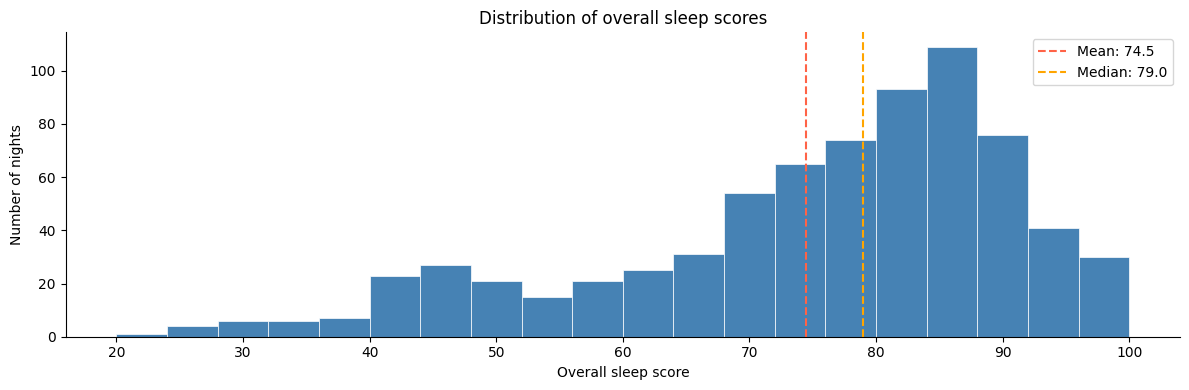

In [16]:
fig, ax = plt.subplots()

ax.hist(
    df['score_overall'].dropna(),
    bins=20,
    color='steelblue',
    edgecolor='white',
    linewidth=0.5
)

ax.axvline(avg_score, color='tomato', linestyle='--', linewidth=1.5, label=f'Mean: {avg_score:.1f}')
ax.axvline(median_score, color='orange', linestyle='--', linewidth=1.5, label=f'Median: {median_score:.1f}')

ax.set_xlabel('Overall sleep score')
ax.set_ylabel('Number of nights')
ax.set_title('Distribution of overall sleep scores')
ax.legend()

plt.tight_layout()
plt.show()

---
## 4. Sleep score over time

Daily scores plotted as faint dots in the background, with a 30-day rolling average as the main line. The rolling average smooths out night-to-night noise and makes longer-term trends easier to see.

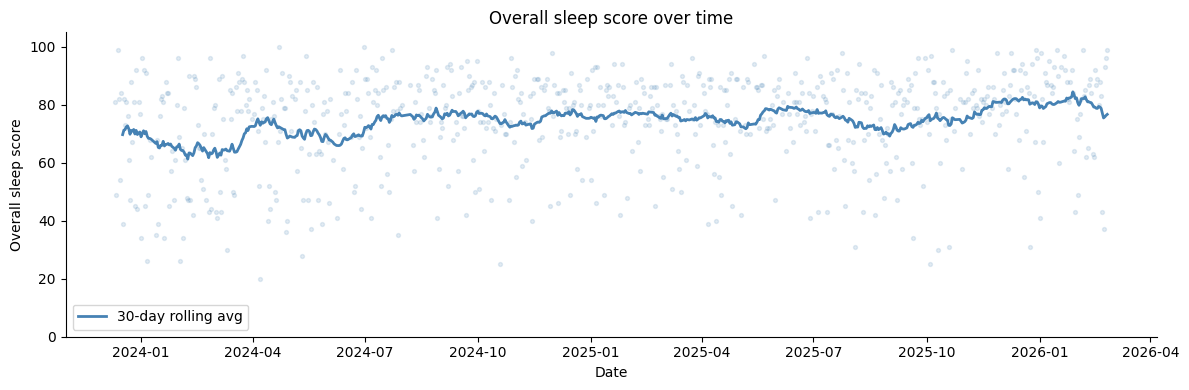

In [17]:
# Monthly average overall score
monthly_score = df.groupby('year_month')['score_overall'].mean()

# 30-day rolling average on the daily data
# Set date as the index temporarily for rolling to work correctly
daily = df.set_index('date')['score_overall'].sort_index()
rolling_score = daily.rolling(window=30, min_periods=7).mean()

fig, ax = plt.subplots()

# Daily scores as faint dots in the background
ax.scatter(
    df['date'], df['score_overall'],
    color='steelblue', alpha=0.15, s=8, zorder=1
)

# 30-day rolling average as the main line
ax.plot(
    rolling_score.index, rolling_score.values,
    color='steelblue', linewidth=2, zorder=2, label='30-day rolling avg'
)

ax.set_xlabel('Date')
ax.set_ylabel('Overall sleep score')
ax.set_title('Overall sleep score over time')
ax.set_ylim(0, 105)
ax.legend()

plt.tight_layout()
plt.savefig("../images/score_over_time.png", dpi=150, bbox_inches='tight')
plt.show()

---
## 5. Sleep duration over time

Same rolling average approach applied to total sleep hours. The dashed reference line marks 7 hours — the commonly cited minimum for adults.

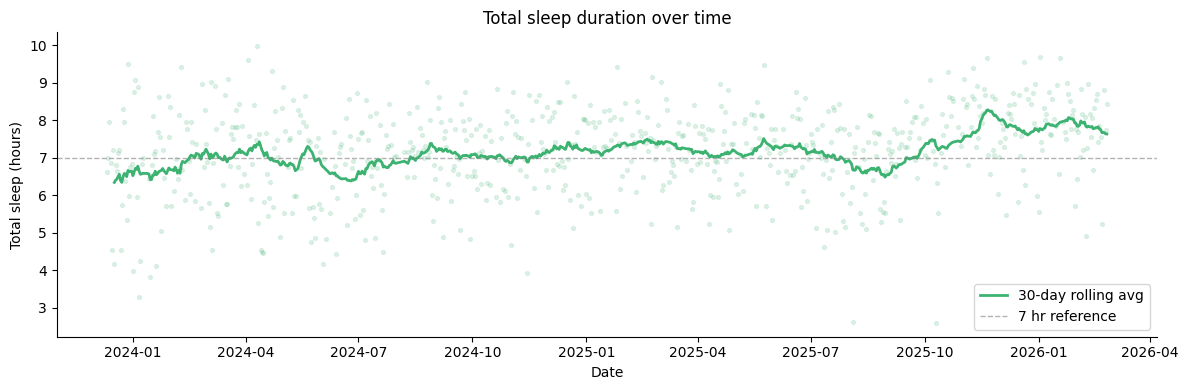

In [18]:
daily_hours = df.set_index('date')['total_sleep_hours'].sort_index()
rolling_hours = daily_hours.rolling(window=30, min_periods=7).mean()

fig, ax = plt.subplots()

ax.scatter(
    df['date'], df['total_sleep_hours'],
    color='mediumseagreen', alpha=0.15, s=8, zorder=1
)
ax.plot(
    rolling_hours.index, rolling_hours.values,
    color='mediumseagreen', linewidth=2, zorder=2, label='30-day rolling avg'
)

# Reference line at 7 hours (commonly recommended minimum)
ax.axhline(7, color='gray', linestyle='--', linewidth=1, alpha=0.6, label='7 hr reference')

ax.set_xlabel('Date')
ax.set_ylabel('Total sleep (hours)')
ax.set_title('Total sleep duration over time')
ax.legend()

plt.tight_layout()
plt.show()

---
## 6. Average sleep stage composition

Average time spent in each sleep stage across all tracked nights. Deep and REM are the most restorative stages; light sleep makes up the largest share for most people.

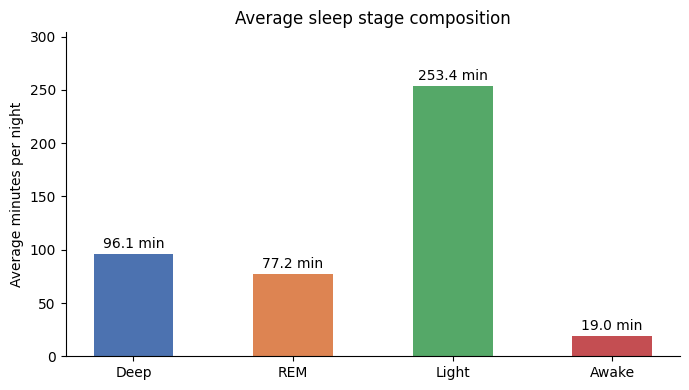

In [19]:
stage_avgs = {
    'Deep': df['deep_sleep_min'].mean(),
    'REM':  df['rem_sleep_min'].mean(),
    'Light': df['light_sleep_min'].mean(),
    'Awake': df['awake_min'].mean(),
}

colors = ['#4c72b0', '#dd8452', '#55a868', '#c44e52']

fig, ax = plt.subplots(figsize=(7, 4))

bars = ax.bar(stage_avgs.keys(), stage_avgs.values(), color=colors, width=0.5)

for bar, val in zip(bars, stage_avgs.values()):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 3,
        f'{val:.1f} min',
        ha='center', va='bottom', fontsize=10
    )

ax.set_ylabel('Average minutes per night')
ax.set_title('Average sleep stage composition')
ax.set_ylim(0, max(stage_avgs.values()) * 1.2)

plt.tight_layout()
plt.show()

---
## 7. Stage composition over time

Monthly averages for each stage stacked into an area chart. Shows whether the overall balance of deep, REM, and light sleep shifted over the tracking period.

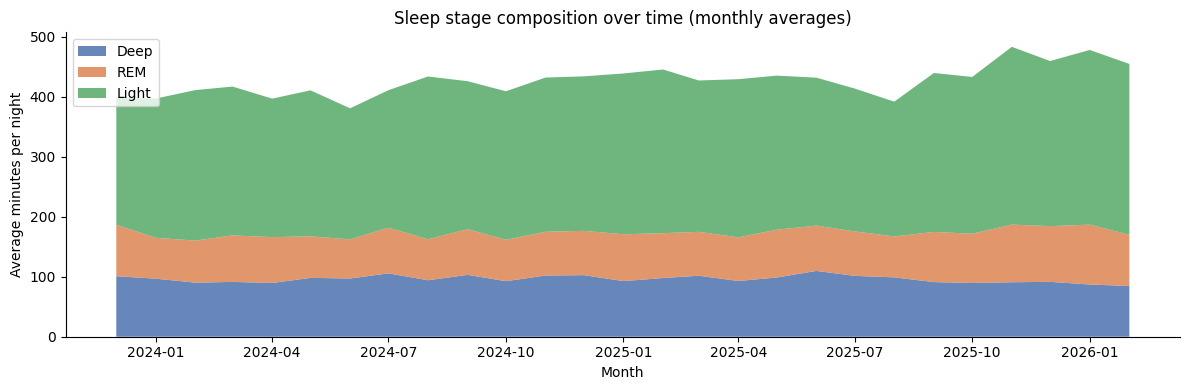

In [20]:
monthly_stages = df.groupby('year_month')[['deep_sleep_min','rem_sleep_min','light_sleep_min']].mean()

# Convert PeriodIndex to timestamps for matplotlib
x = monthly_stages.index.to_timestamp()

fig, ax = plt.subplots()

ax.stackplot(
    x,
    monthly_stages['deep_sleep_min'],
    monthly_stages['rem_sleep_min'],
    monthly_stages['light_sleep_min'],
    labels=['Deep', 'REM', 'Light'],
    colors=['#4c72b0', '#dd8452', '#55a868'],
    alpha=0.85
)

ax.set_xlabel('Month')
ax.set_ylabel('Average minutes per night')
ax.set_title('Sleep stage composition over time (monthly averages)')
ax.legend(loc='upper left')

plt.tight_layout()
plt.show()

---
## 8. Sleep by day of week

Average score and duration broken out by day. Weekends are highlighted in red — useful for spotting whether sleep patterns differ meaningfully on non-work days.

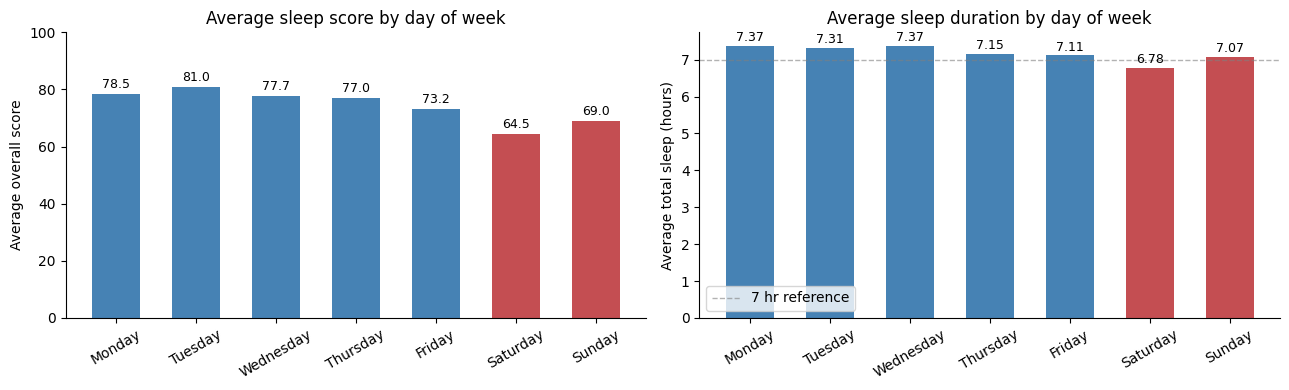

In [21]:
dow_order = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']

dow = (
    df.groupby('day_of_week')[['score_overall','total_sleep_hours']]
    .mean()
    .reindex(dow_order)
)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4))

# Score by day
bar_colors = ['#c44e52' if d in ['Saturday','Sunday'] else 'steelblue' for d in dow_order]

ax1.bar(dow.index, dow['score_overall'], color=bar_colors, width=0.6)
ax1.set_ylabel('Average overall score')
ax1.set_title('Average sleep score by day of week')
ax1.set_ylim(0, 100)
ax1.tick_params(axis='x', rotation=30)
for i, val in enumerate(dow['score_overall']):
    ax1.text(i, val + 1, f'{val:.1f}', ha='center', va='bottom', fontsize=9)

# Duration by day
ax2.bar(dow.index, dow['total_sleep_hours'], color=bar_colors, width=0.6)
ax2.axhline(7, color='gray', linestyle='--', linewidth=1, alpha=0.6, label='7 hr reference')
ax2.set_ylabel('Average total sleep (hours)')
ax2.set_title('Average sleep duration by day of week')
ax2.tick_params(axis='x', rotation=30)
ax2.legend()
for i, val in enumerate(dow['total_sleep_hours']):
    ax2.text(i, val + 0.05, f'{val:.2f}', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.savefig("../images/day_of_week.png", dpi=150, bbox_inches='tight')
plt.show()

---
## 9. Feedback label breakdown

Garmin assigns a qualitative label to each night (e.g. `positive long and deep`, `negative not restorative`). This shows the most common labels across all tracked nights, colored by sentiment.

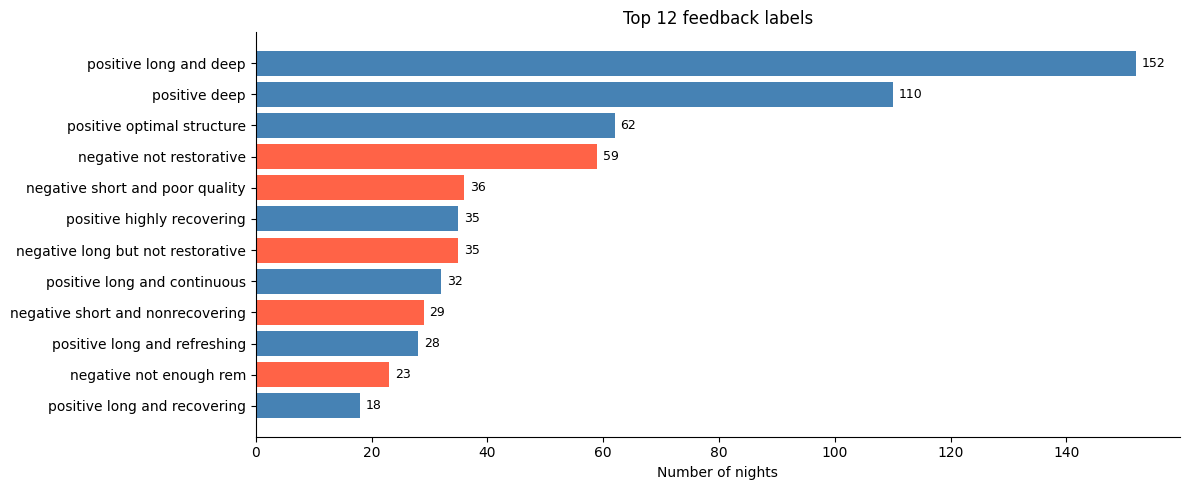

In [22]:
top_labels = df['feedback'].value_counts().head(12)

label_colors = [
    'steelblue' if 'positive' in label else 'tomato'
    for label in top_labels.index
]

fig, ax = plt.subplots(figsize=(12, 5))

ax.barh(top_labels.index[::-1], top_labels.values[::-1], color=label_colors[::-1])
ax.set_xlabel('Number of nights')
ax.set_title('Top 12 feedback labels')

for i, val in enumerate(top_labels.values[::-1]):
    ax.text(val + 1, i, str(val), va='center', fontsize=9)

plt.tight_layout()
plt.show()

---
## 10. Positive feedback rate over time

The share of nights Garmin rated as positive, plotted month by month. Fill above 50% is blue; below is red. Makes it easy to spot stretches of consistently good or poor sleep.

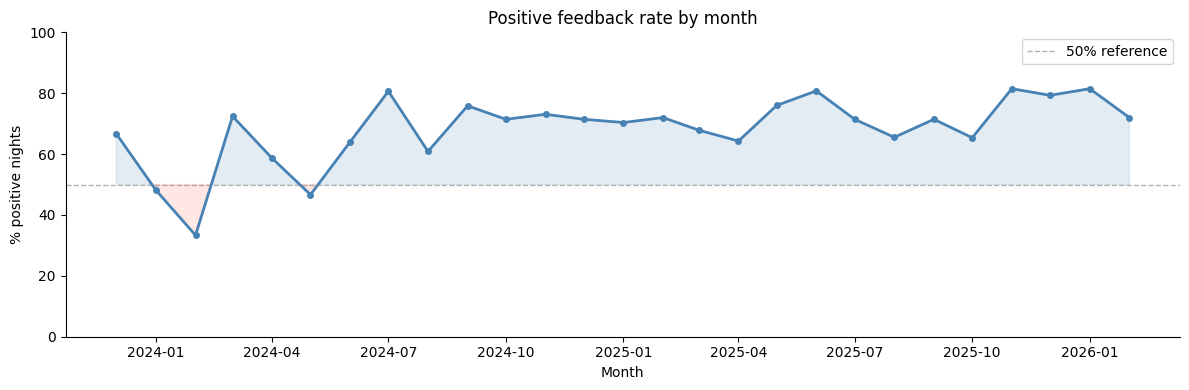

In [23]:
monthly_sentiment = df.groupby('year_month')['feedback_sentiment'].apply(
    lambda x: (x == 'positive').mean() * 100
)

x = monthly_sentiment.index.to_timestamp()

fig, ax = plt.subplots()

ax.plot(x, monthly_sentiment.values, color='steelblue', linewidth=2, marker='o', markersize=4)
ax.axhline(50, color='gray', linestyle='--', linewidth=1, alpha=0.6, label='50% reference')
ax.fill_between(x, monthly_sentiment.values, 50, 
                where=(monthly_sentiment.values >= 50),
                alpha=0.15, color='steelblue', interpolate=True)
ax.fill_between(x, monthly_sentiment.values, 50,
                where=(monthly_sentiment.values < 50),
                alpha=0.15, color='tomato', interpolate=True)

ax.set_xlabel('Month')
ax.set_ylabel('% positive nights')
ax.set_title('Positive feedback rate by month')
ax.set_ylim(0, 100)
ax.legend()

plt.tight_layout()
plt.show()

---
## 11. Nap vs. no nap

Do nights following a nap score differently? The overlapping histograms show the score distribution for both groups. Note that lower scores on nap days likely reflect reverse causality — naps tend to follow poor nights rather than cause them.

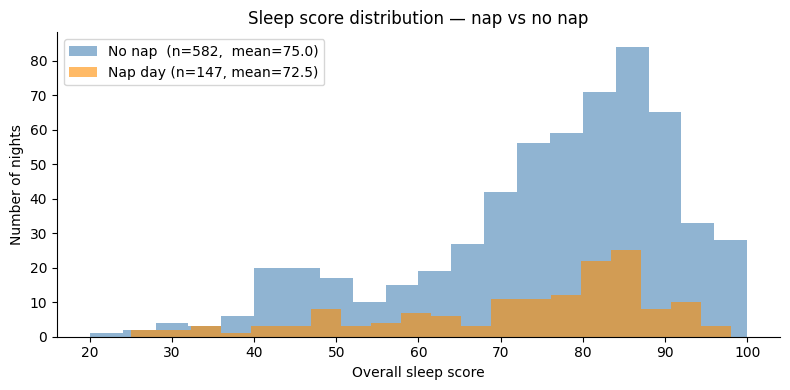

In [24]:
nap_yes = df[df['had_nap'] == True]['score_overall'].dropna()
nap_no  = df[df['had_nap'] == False]['score_overall'].dropna()

fig, ax = plt.subplots(figsize=(8, 4))

ax.hist(nap_no,  bins=20, alpha=0.6, color='steelblue',  label=f'No nap  (n={len(nap_no)},  mean={nap_no.mean():.1f})')
ax.hist(nap_yes, bins=20, alpha=0.6, color='darkorange', label=f'Nap day (n={len(nap_yes)}, mean={nap_yes.mean():.1f})')

ax.set_xlabel('Overall sleep score')
ax.set_ylabel('Number of nights')
ax.set_title('Sleep score distribution — nap vs no nap')
ax.legend()

plt.tight_layout()
plt.show()


---
## 12. Bedtime distribution

What time did I actually go to bed? `bed_hour` was stored in UTC in the cleaned dataset — subtracting 5 converts it to Eastern Time. This shows the spread of bedtimes across all tracked nights.

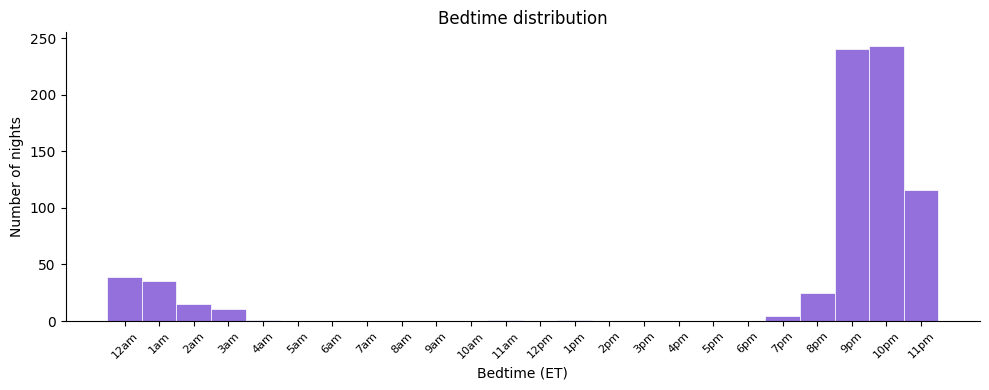

In [25]:
df['bed_hour_et'] = (df['bed_hour'] - 5) % 24

fig, ax = plt.subplots(figsize=(10, 4))

ax.hist(
    df['bed_hour_et'].dropna(),
    bins=range(0, 25),
    color='mediumpurple',
    edgecolor='white',
    linewidth=0.5,
    align='left'
)

# Label hours in a human-readable format
hour_labels = [f'{h % 12 or 12}{"am" if h < 12 else "pm"}' for h in range(0, 24)]
ax.set_xticks(range(0, 24))
ax.set_xticklabels(hour_labels, rotation=45, fontsize=8)
ax.set_xlabel('Bedtime (ET)')
ax.set_ylabel('Number of nights')
ax.set_title('Bedtime distribution')

plt.tight_layout()
plt.show()

---
## 13. Sleep score by bedtime

Narrowing to the core bedtime window (8pm–2am ET), does going to bed later correlate with a lower score? Each bar shows the average overall score for nights that started in that hour.

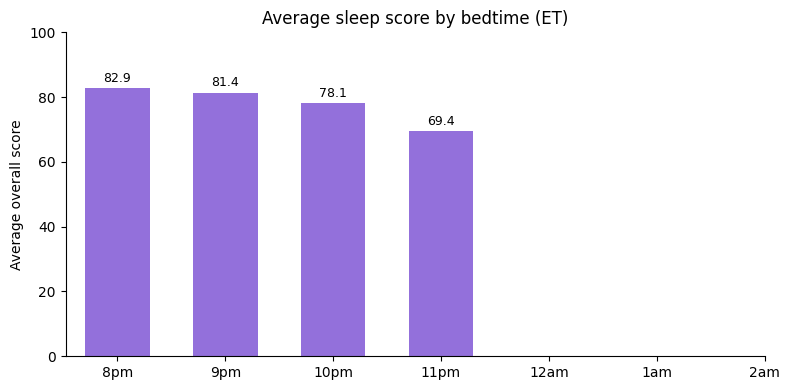

In [26]:
df_bt = df[df['bed_hour_et'].between(20, 26, inclusive='both')].dropna(subset=['score_overall'])

avg_by_hour = df_bt.groupby('bed_hour_et')['score_overall'].mean()

fig, ax = plt.subplots(figsize=(8, 4))

ax.bar(
    avg_by_hour.index,
    avg_by_hour.values,
    color='mediumpurple',
    width=0.6
)

hour_labels = {20: '8pm', 21: '9pm', 22: '10pm', 23: '11pm', 24: '12am', 25: '1am', 26: '2am'}
ax.set_xticks(list(hour_labels.keys()))
ax.set_xticklabels(list(hour_labels.values()))
ax.set_ylabel('Average overall score')
ax.set_title('Average sleep score by bedtime (ET)')
ax.set_ylim(0, 100)

for i, (hour, val) in enumerate(avg_by_hour.items()):
    ax.text(hour, val + 1, f'{val:.1f}', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.savefig("../images/score_by_bedtime.png", dpi=150, bbox_inches='tight')
plt.show()

## Summary

A few takeaways from 2+ years of nightly sleep data:

- **Consistent overall.** An average score in the mid-70s and just over 7 hours of sleep per night, sustained across the full tracking period. No dramatic long-term trends up or down.
- **Weekends are worse.** Lower scores and shorter duration on Saturdays and Sundays... weekends are in fact not for resting. 
- **Bedtime matters.** Later bedtimes correlate with lower sleep scores. Going to bed at 10pm vs 11pm is associated with almost a 10-point difference in overall score.